# Ensidig ANOVA — Python-beregninger

Denne notatboken inneholder alle Python-beregningene fra beamer-presentasjonen
**«Ensidig ANOVA»**, i samme rekkefølge som slidene:

1. Forutsetninger for hypotesetest (Q–Q-plott, skjevhet/kurtosis, Shapiro–Wilk, Levene)
2. Ensidig ANOVA: forutsetningssjekk, ANOVA-tabell, $F$-fordeling, post-hoc (Tukey HSD)

Alt er beregnet med `numpy`, `scipy.stats`, `statsmodels` og `matplotlib`.



In [2]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

np.random.seed(2026)
plt.rcParams["figure.figsize"] = (6, 4)
ORANGE = "#E8743B"
BLUE = "#1f4e8c"
GRAY = "#888888"


---
## 1. Forutsetninger for hypotesetest

### Eksempel: Q–Q-plott for aldersfordeling i en klasse

**Data:** Alder på $N=13$ studenter (og læreren) i en klasse.

In [2]:
age = np.array([21, 22, 23, 23, 24, 25, 26, 26, 30, 31, 32, 43, 44])
N = len(age)
mu, sigma = age.mean(), age.std(ddof=1)
print(f"N={N}, gjennomsnitt={mu:.2f}, standardavvik={sigma:.2f}")

N=13, gjennomsnitt=28.46, standardavvik=7.50


In [3]:
# Plotting positions (i-0.5)/N og teoretiske kvantiler
p = (np.arange(1, N+1) - 0.5) / N
theoretical = stats.norm.ppf(p, mu, sigma)
observed = np.sort(age)

tabell = pd.DataFrame({
    "Persentil (%)": (p*100).round(1),
    "Alder (observert)": observed,
    "Teoretisk verdi": theoretical.round(1)
})
print(tabell.to_string(index=False))

 Persentil (%)  Alder (observert)  Teoretisk verdi
           3.8                 21             15.2
          11.5                 22             19.5
          19.2                 23             21.9
          26.9                 23             23.8
          34.6                 24             25.5
          42.3                 25             27.0
          50.0                 26             28.5
          57.7                 26             29.9
          65.4                 30             31.4
          73.1                 31             33.1
          80.8                 32             35.0
          88.5                 43             37.5
          96.2                 44             41.7


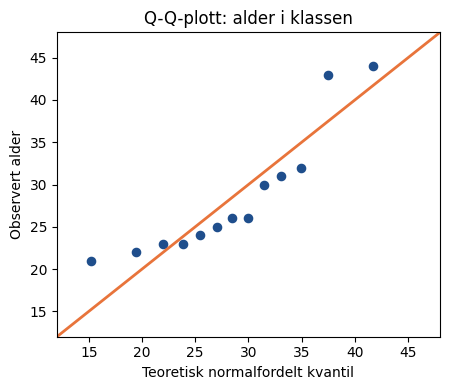

In [4]:
fig, ax = plt.subplots(figsize=(4.6, 4.0))
lims = [12, 48]
ax.plot(lims, lims, color=ORANGE, lw=2)
ax.scatter(theoretical, observed, color=BLUE, s=35)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Teoretisk normalfordelt kvantil")
ax.set_ylabel("Observert alder")
ax.set_title("Q-Q-plott: alder i klassen")
plt.tight_layout()
plt.show()

# Enklere: stats.probplot(age, dist="norm", plot=plt)

### Tolkning: skjevhet, kurtosis og Shapiro–Wilk

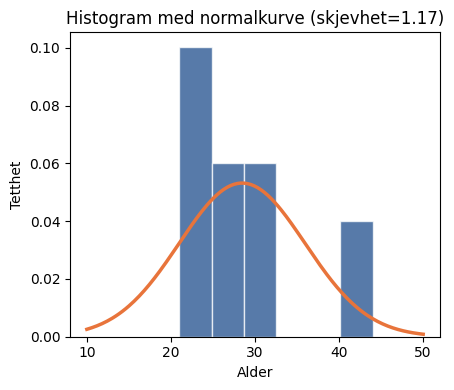

Skjevhet (skewness): 1.1749552101492264
Kurtosis: 0.1481049139969164
Shapiro-Wilk: ShapiroResult(statistic=np.float64(0.8219617868008289), pvalue=np.float64(0.012580124968096832))


In [5]:
fig, ax = plt.subplots(figsize=(4.6, 4.0))
ax.hist(age, bins=6, color=BLUE, alpha=0.75, edgecolor="white", density=True)
x = np.linspace(10, 50, 200)
ax.plot(x, stats.norm.pdf(x, mu, sigma), color=ORANGE, lw=2.5)
ax.set_xlabel("Alder"); ax.set_ylabel("Tetthet")
ax.set_title(f"Histogram med normalkurve (skjevhet={stats.skew(age):.2f})")
plt.tight_layout()
plt.show()

print("Skjevhet (skewness):", stats.skew(age))
print("Kurtosis:", stats.kurtosis(age))
print("Shapiro-Wilk:", stats.shapiro(age))

**Tolkning:** Positiv skjevhet ($1.17$), og Shapiro–Wilk gir $p=0.013<0.05$
$\Rightarrow$ dataene er trolig ikke normalfordelte (lite overraskende med få, skjeve data).

### Levenes test for lik varians (generisk eksempel)

In [6]:
# Illustrasjon av syntaks (brukes senere med ekte grupper)
eksempel_g1 = np.array([1, 2, 3, 4, 5])
eksempel_g2 = np.array([2, 2, 3, 3, 4])
print(stats.levene(eksempel_g1, eksempel_g2))
print("p > 0.05 => ingen grunn til aa tro paa ulik varians.")

LeveneResult(statistic=np.float64(1.7999999999999998), pvalue=np.float64(0.21654728411266932))
p > 0.05 => ingen grunn til aa tro paa ulik varians.


---
## 2. Ensidig ANOVA

**Oppgave:** Tre typer gjødsel testes på $6$ planter hver. Er det forskjell i
gjennomsnittlig plantehøyde mellom gjødseltypene ($\alpha=0.05$)?

In [3]:
gA = np.array([23, 25, 21, 24, 22, 26])
gB = np.array([28, 30, 27, 31, 29, 26])
gC = np.array([20, 22, 19, 23, 21, 18])

for navn, g in zip(["A", "B", "C"], [gA, gB, gC]):
    print(f"{navn}: mean={g.mean():.2f}, sd={g.std(ddof=1):.2f}, "
          f"Shapiro p={stats.shapiro(g).pvalue:.3f}")

print("\nLevene:", stats.levene(gA, gB, gC))

A: mean=23.50, sd=1.87, Shapiro p=0.961
B: mean=28.50, sd=1.87, Shapiro p=0.961
C: mean=20.50, sd=1.87, Shapiro p=0.961

Levene: LeveneResult(statistic=np.float64(0.0), pvalue=np.float64(1.0))


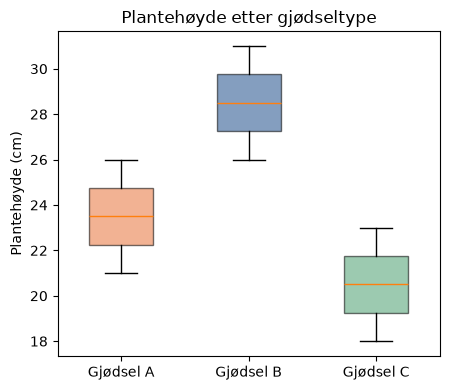

In [4]:
fig, ax = plt.subplots(figsize=(4.6, 4.0))
bp = ax.boxplot([gA, gB, gC], tick_labels=["Gjødsel A", "Gjødsel B", "Gjødsel C"],
                patch_artist=True, widths=0.5)
for patch, color in zip(bp['boxes'], [ORANGE, BLUE, "#4C9F70"]):
    patch.set_facecolor(color); patch.set_alpha(0.55)
ax.set_ylabel("Plantehøyde (cm)")
ax.set_title("Plantehøyde etter gjødseltype")
plt.tight_layout()
plt.show()

Alle $p$-verdier $>0.05$: verken normalitets- eller variansantakelsen er i tvil her.

In [5]:
df_data = pd.DataFrame({
    "verdi": np.concatenate([gA, gB, gC]),
    "gruppe": ["A"]*6 + ["B"]*6 + ["C"]*6
})

model = ols("verdi ~ gruppe", data=df_data).fit()
anova_table = sm.stats.anova_lm(model)
print(anova_table)

SSG = anova_table["sum_sq"].iloc[0]
SSE = anova_table["sum_sq"].iloc[1]
eta2 = SSG / (SSG + SSE)
print(f"\neta^2 = {eta2:.3f}")

            df  sum_sq  mean_sq     F    PR(>F)
gruppe     2.0   196.0     98.0  28.0  0.000009
Residual  15.0    52.5      3.5   NaN       NaN

eta^2 = 0.789


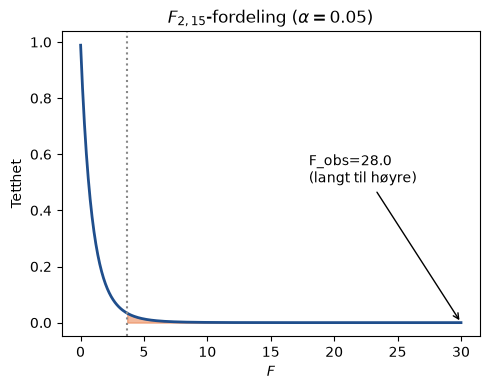

F_obs = 28.00, F_krit(0.05) = 3.68


In [6]:
dfG, dfE = 2, 15
F_obs = anova_table["F"].iloc[0]
Fcrit = stats.f.ppf(0.95, dfG, dfE)

fig, ax = plt.subplots(figsize=(5.0, 4.0))
x = np.linspace(0.01, 30, 400)
ax.plot(x, stats.f.pdf(x, dfG, dfE), color=BLUE, lw=2)
xr = np.linspace(Fcrit, 30, 100)
ax.fill_between(xr, stats.f.pdf(xr, dfG, dfE), color=ORANGE, alpha=0.5)
ax.axvline(Fcrit, color=GRAY, linestyle=":")
ax.annotate(f"F_obs={F_obs:.1f}\n(langt til høyre)", xy=(30, 0), xytext=(18, 0.5),
            arrowprops=dict(arrowstyle="->"))
ax.set_xlabel("$F$"); ax.set_ylabel("Tetthet")
ax.set_title(f"$F_{{{dfG},{dfE}}}$-fordeling ($\\alpha=0.05$)")
plt.tight_layout()
plt.show()

print(f"F_obs = {F_obs:.2f}, F_krit(0.05) = {Fcrit:.2f}")

**Konklusjon:** $F(2,15)=28.0$, $p\approx8.6\times10^{-6}<0.05$ $\Rightarrow$
**forkast $H_0$**: gjødseltype påvirker plantehøyden. $\eta^2\approx0.79$ (stor effekt).

### Effektstørrelse: $\eta^2$

$\eta^2$ måler hvor stor andel av den totale variasjonen i responsen som skyldes gruppeforskjellen:

$$
\eta^{2} = \frac{SS_{\text{gruppe}}}{SS_{\text{total}}} = \frac{SSG}{SSG+SSE}
$$

Cohens tommelfingerregler: $0.01$ liten, $0.06$ middels, $0.14$ stor effekt.

In [11]:
SST = SSG + SSE
eta2 = SSG / SST

print(f"SSG = {SSG:.2f}")
print(f"SSE = {SSE:.2f}")
print(f"SST = {SST:.2f}")
print(f"eta^2 = {eta2:.3f}")

if eta2 < 0.06:
    tolkning = "liten"
elif eta2 < 0.14:
    tolkning = "middels"
else:
    tolkning = "stor"

print(f"\nAndel av variasjonen i plantehøyde forklart av gjødseltype: {eta2*100:.0f}%")
print(f"Tolkning (Cohens tommelfingerregler): {tolkning} effekt")

SSG = 196.00
SSE = 52.50
SST = 248.50
eta^2 = 0.789

Andel av variasjonen i plantehøyde forklart av gjødseltype: 79%
Tolkning (Cohens tommelfingerregler): stor effekt


### Post-hoc-test: Tukeys HSD

In [7]:
post = pairwise_tukeyhsd(df_data["verdi"], df_data["gruppe"])
print(post)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     A      B      5.0 0.0009   2.1944  7.8056   True
     A      C     -3.0 0.0355  -5.8056 -0.1944   True
     B      C     -8.0    0.0 -10.8056 -5.1944   True
-----------------------------------------------------


**Tolkning:** Alle tre gjødseltypene skiller seg signifikant fra hverandre ---
gjødsel B gir høyest plantehøyde, gjødsel C lavest.